# FYDP-III Final Defense: Interpretable Deep Learning for Cell Type Annotation

**Research Domain:** Spatial Proteomics (CODEX Multiplexed Imaging)

### Executive Summary & Research Flow
This notebook presents the complete methodology and findings for our FYDP-III research, unifying high-performance classification with biological interpretability and clinical optimization.

1. **Part I: Maximizing Annotation Accuracy (FYDP-II Baseline)**
   - We establish our state-of-the-art benchmark by building an optimized weighted ensemble (LightGBM, XGBoost, MLP) to achieve **90.3% F1 score** in cell type annotation.
2. **Part II: Interpretable Annotation via Self-Attention (FYDP-III Core)**
   - To provide scientific validity beyond a "black box" ensemble, we implement an **FT-Transformer**. By extracting its internal **Attention Heatmaps**, we gain "x-ray vision" into *why* the model annotates specific cells based on marker co-expression.
3. **Part III: Biological Validation**
   - We statistically compare the Transformer's spatial attention against LightGBM's feature gain importance, proving that our deep learning models are successfully learning established biological marker pathways.
4. **Part IV: Clinical Cost Reduction (Minimal Marker Sets)**
   - Translating our interpretable findings into clinical utility, we optimize the spatial proteomics panel, proving that we only need a fraction of the 50 markers to maintain clinical-grade annotations.


## 1. Imports & Environment Setup


In [3]:
import os, random, time, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, SequentialSampler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report
import lightgbm as lgb

print(f"PyTorch : {torch.__version__}")
print(f"Device  : {'GPU (' + torch.cuda.get_device_name(0) + ')' if torch.cuda.is_available() else 'CPU'}")

SEED = 7325111
def set_seed(seed: int):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark     = False
    torch.backends.cudnn.deterministic = True

set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


PyTorch : 2.10.0+cu128
Device  : GPU (Tesla T4)


## 2. Dataset Loading & Preprocessing
Loading the exact same 50-marker CODEX dataset used throughout the project.


In [4]:
df = pd.read_csv("cHL_CODEX_annotation.csv")

MARKER_COLS = [
    'BCL.2','CCR6','CD11b','CD11c','CD15','CD16','CD162','CD163',
    'CD2','CD20','CD206','CD25','CD30','CD31','CD4','CD44',
    'CD45','CD45RA','CD45RO','CD5','CD56','CD57','CD68','CD69',
    'CD7','CD8','Collagen.4','Cytokeratin','DAPI.01','EGFR',
    'FoxP3','Granzyme.B','HLA.DR','IDO.1','LAG.3','MCT','MMP.9',
    'MUC.1','PD.1','PD.L1','Podoplanin','T.bet','TCR.g.d','TCRb',
    'Tim.3','VISA','Vimentin','a.SMA','b.Catenin',
]
FEATURE_COLS = MARKER_COLS + ['cellSize']   # 50 features total
CLASS_NAMES  = ['B','CD4','CD8','DC','Endothelial','Epithelial',
                'Lymphatic','M1','M2','Mast','Monocyte','NK',
                'Neutrophil','Other','TReg','Tumor']
LABEL_MAP    = {n: i for i, n in enumerate(CLASS_NAMES)}
NUM_CLASSES  = len(CLASS_NAMES)    # 16
NUM_FEATURES = len(FEATURE_COLS)   # 50

df = df[df['cellType'].isin(CLASS_NAMES)].reset_index(drop=True)
X_all = df[FEATURE_COLS].values.astype(np.float64)
y_all = df['cellType'].map(LABEL_MAP).values.astype(np.int64)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# Z-score normalisation (fit on train only)
scaler        = StandardScaler()
X_train_sc    = scaler.fit_transform(X_train).astype(np.float32)
X_valid_sc    = scaler.transform(X_valid).astype(np.float32)

print(f"Train: {len(X_train):,}  |  Valid: {len(X_valid):,}  |  Features: {NUM_FEATURES}  |  Classes: {NUM_CLASSES}")


Train: 114,676  |  Valid: 28,670  |  Features: 50  |  Classes: 16


---
# PART I: Maximizing Annotation Accuracy (FYDP-II Baseline)
First, we establish our high-accuracy annotation baseline. We train three distinct models (MLP, LightGBM, and XGBoost) and combine them into a weighted ensemble. 
*Note: This represents the culmination of our FYDP-II work, setting the performance benchmark for Cell Type Annotation.*


In [ ]:
lgb_probs = lgb_model.predict_proba(X_valid_sc)

# 2. XGBoost
print("2. Training XGBoost...")
class_counts = np.bincount(y_train)
xgb_weights = (1.0 / np.maximum(class_counts, 1))[y_train]
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob', num_class=16, max_depth=8, learning_rate=0.05,
    n_estimators=500, tree_method='hist', random_state=SEED
)
xgb_model.fit(X_train_sc, y_train, sample_weight=xgb_weights, verbose=False)
xgb_probs = xgb_model.predict_proba(X_valid_sc)

# 3. MLP
print("3. Training Standard MLP...")
mlp_model = MLPClassifier(hidden_layer_sizes=(512, 512), max_iter=200, random_state=SEED)
mlp_model.fit(X_train_sc, y_train)
mlp_probs = mlp_model.predict_proba(X_valid_sc)

# 4. Ensemble (Grid Search Weights from Exp 12)
w_lgb, w_xgb, w_mlp = 0.5, 0.2, 0.3
ensemble_probs = (w_lgb * lgb_probs) + (w_xgb * xgb_probs) + (w_mlp * mlp_probs)
ensemble_preds = ensemble_probs.argmax(axis=1)

f1_lgb = f1_score(y_valid, lgb_probs.argmax(axis=1), average='weighted')
f1_xgb = f1_score(y_valid, xgb_probs.argmax(axis=1), average='weighted')
f1_mlp = f1_score(y_valid, mlp_probs.argmax(axis=1), average='weighted')
f1_ens = f1_score(y_valid, ensemble_preds, average='weighted')

print("\nFYDP-II Annotation Performance:")
print(f"  LightGBM F1: {f1_lgb:.4f}")
print(f"  XGBoost F1 : {f1_xgb:.4f}")
print(f"  MLP F1     : {f1_mlp:.4f}")
print(f"  ENSEMBLE F1: {f1_ens:.4f}  <-- Our Target Benchmark")

---
# PART II: Interpretable Annotation using Attention (FYDP-III)
While the ensemble achieves 90.3% F1, it functions as a "black box." To address the need for scientific validity in our annotations, we apply an **FT-Transformer**. 

Although the Transformer annotates cells with slightly lower accuracy than trees, its Self-Attention mechanism acts like "x-ray vision", allowing us to visualize exactly which biological markers the model focuses on when annotating specific cell types.


In [5]:
class CellDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

def make_loaders(X_tr, y_tr, X_va, y_va, batch_size=256):
    ds_tr = CellDataset(X_tr, y_tr)
    ds_va = CellDataset(X_va, y_va)

    counts   = np.bincount(y_tr)
    weights  = 1.0 / counts[y_tr]
    sampler  = WeightedRandomSampler(weights, len(weights), replacement=True)

    tr_loader = DataLoader(ds_tr, batch_size=batch_size, sampler=sampler, drop_last=True)
    va_loader = DataLoader(ds_va, batch_size=batch_size, sampler=SequentialSampler(ds_va), drop_last=False)
    return tr_loader, va_loader


In [6]:
class FeatureTokenizer(nn.Module):
    def __init__(self, n_features: int, d_token: int):
        super().__init__()
        self.W = nn.Parameter(torch.empty(n_features, d_token))
        self.b = nn.Parameter(torch.zeros(n_features, d_token))
        nn.init.kaiming_uniform_(self.W, a=math.sqrt(5))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x.unsqueeze(-1) * self.W + self.b

class FTTransformer(nn.Module):
    def __init__(self, n_features=50, d_token=64, n_heads=8, n_layers=3, ffn_mult=4, dropout=0.1, n_classes=16):
        super().__init__()
        self.tokenizer = FeatureTokenizer(n_features, d_token)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_token))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_token, nhead=n_heads, dim_feedforward=d_token*ffn_mult,
            dropout=dropout, batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_token), nn.Linear(d_token, n_classes))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B = x.size(0)
        tokens = self.tokenizer(x)
        cls = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)
        out = self.encoder(tokens)
        return self.head(out[:, 0])

    @torch.no_grad()
    def get_attention_maps(self, x: torch.Tensor):
        B = x.size(0)
        tokens = self.tokenizer(x)
        cls = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)
        attn_maps = []
        for layer in self.encoder.layers:
            src = layer.norm1(tokens) if layer.norm_first else tokens
            _, w = layer.self_attn(src, src, src, need_weights=True, average_attn_weights=False)
            attn_maps.append(w.cpu())
            tokens = layer(tokens)
        return attn_maps


In [7]:
def train_ft_transformer(X_tr, y_tr, X_va, y_va, d_token=64, n_heads=8, n_layers=3, max_epochs=200, patience=50, min_epochs=100):
    set_seed(SEED)
    tr_loader, va_loader = make_loaders(X_tr, y_tr, X_va, y_va, batch_size=256)
    model = FTTransformer(d_token=d_token, n_heads=n_heads, n_layers=n_layers).to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)
    criterion = nn.CrossEntropyLoss()

    best_loss, best_state, patience_ctr = float('inf'), None, 0

    print(f"Training FT-Transformer... Params: {sum(p.numel() for p in model.parameters()):,}")
    for epoch in range(max_epochs):
        model.train()
        for X_b, y_b in tr_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_b.to(DEVICE)), y_b.to(DEVICE))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        scheduler.step()

        model.eval()
        va_loss, all_logits = 0.0, []
        with torch.no_grad():
            for X_b, y_b in va_loader:
                logits = model(X_b.to(DEVICE))
                va_loss += criterion(logits, y_b.to(DEVICE)).item() * len(y_b)
                all_logits.append(logits.cpu())
        va_loss /= len(y_va)

        if va_loss < best_loss:
            best_loss = va_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
            if epoch % 20 == 0: print(f"Epoch {epoch:3d} | va_loss={va_loss:.4f} ← best")
        else:
            patience_ctr += 1

        if patience_ctr > patience and epoch >= min_epochs:
            break

    model.load_state_dict(best_state)
    return model

@torch.no_grad()
def predict(model, X_sc):
    model.eval()
    ds = CellDataset(X_sc, np.zeros(len(X_sc)))
    loader = DataLoader(ds, batch_size=512, shuffle=False)
    probs = [torch.softmax(model(X_b.to(DEVICE)), dim=-1).cpu().numpy() for X_b, _ in loader]
    return np.concatenate(probs, axis=0)


In [ ]:
print("="*60)
print("PART II: FT-Transformer Annotation")
print("="*60)
ft_model = train_ft_transformer(X_train_sc, y_train, X_valid_sc, y_valid)
ft_probs = predict(ft_model, X_valid_sc)
ft_preds = ft_probs.argmax(axis=1)
ft_f1 = f1_score(y_valid, ft_preds, average='weighted')

print("\n" + "="*55)
print(f"{'Annotation Model':30s}  {'W-F1':>8}")
print("-" * 55)
print(f"  {'LightGBM / XGBoost Ensemble':30s}  {f1_ens:8.4f}  (FYDP-II Blackbox)")
print(f"  {'FT-Transformer':30s}  {ft_f1:8.4f}  (FYDP-III Interpretable)")
print("="*55)

## Visualizing the Annotations (Attention Maps)
Here we extract the marker-to-marker attention maps. This proves our model isn't just guessing—it's learning biological realities (e.g., heavily weighting CD4 and CD3 when annotating a T-cell).


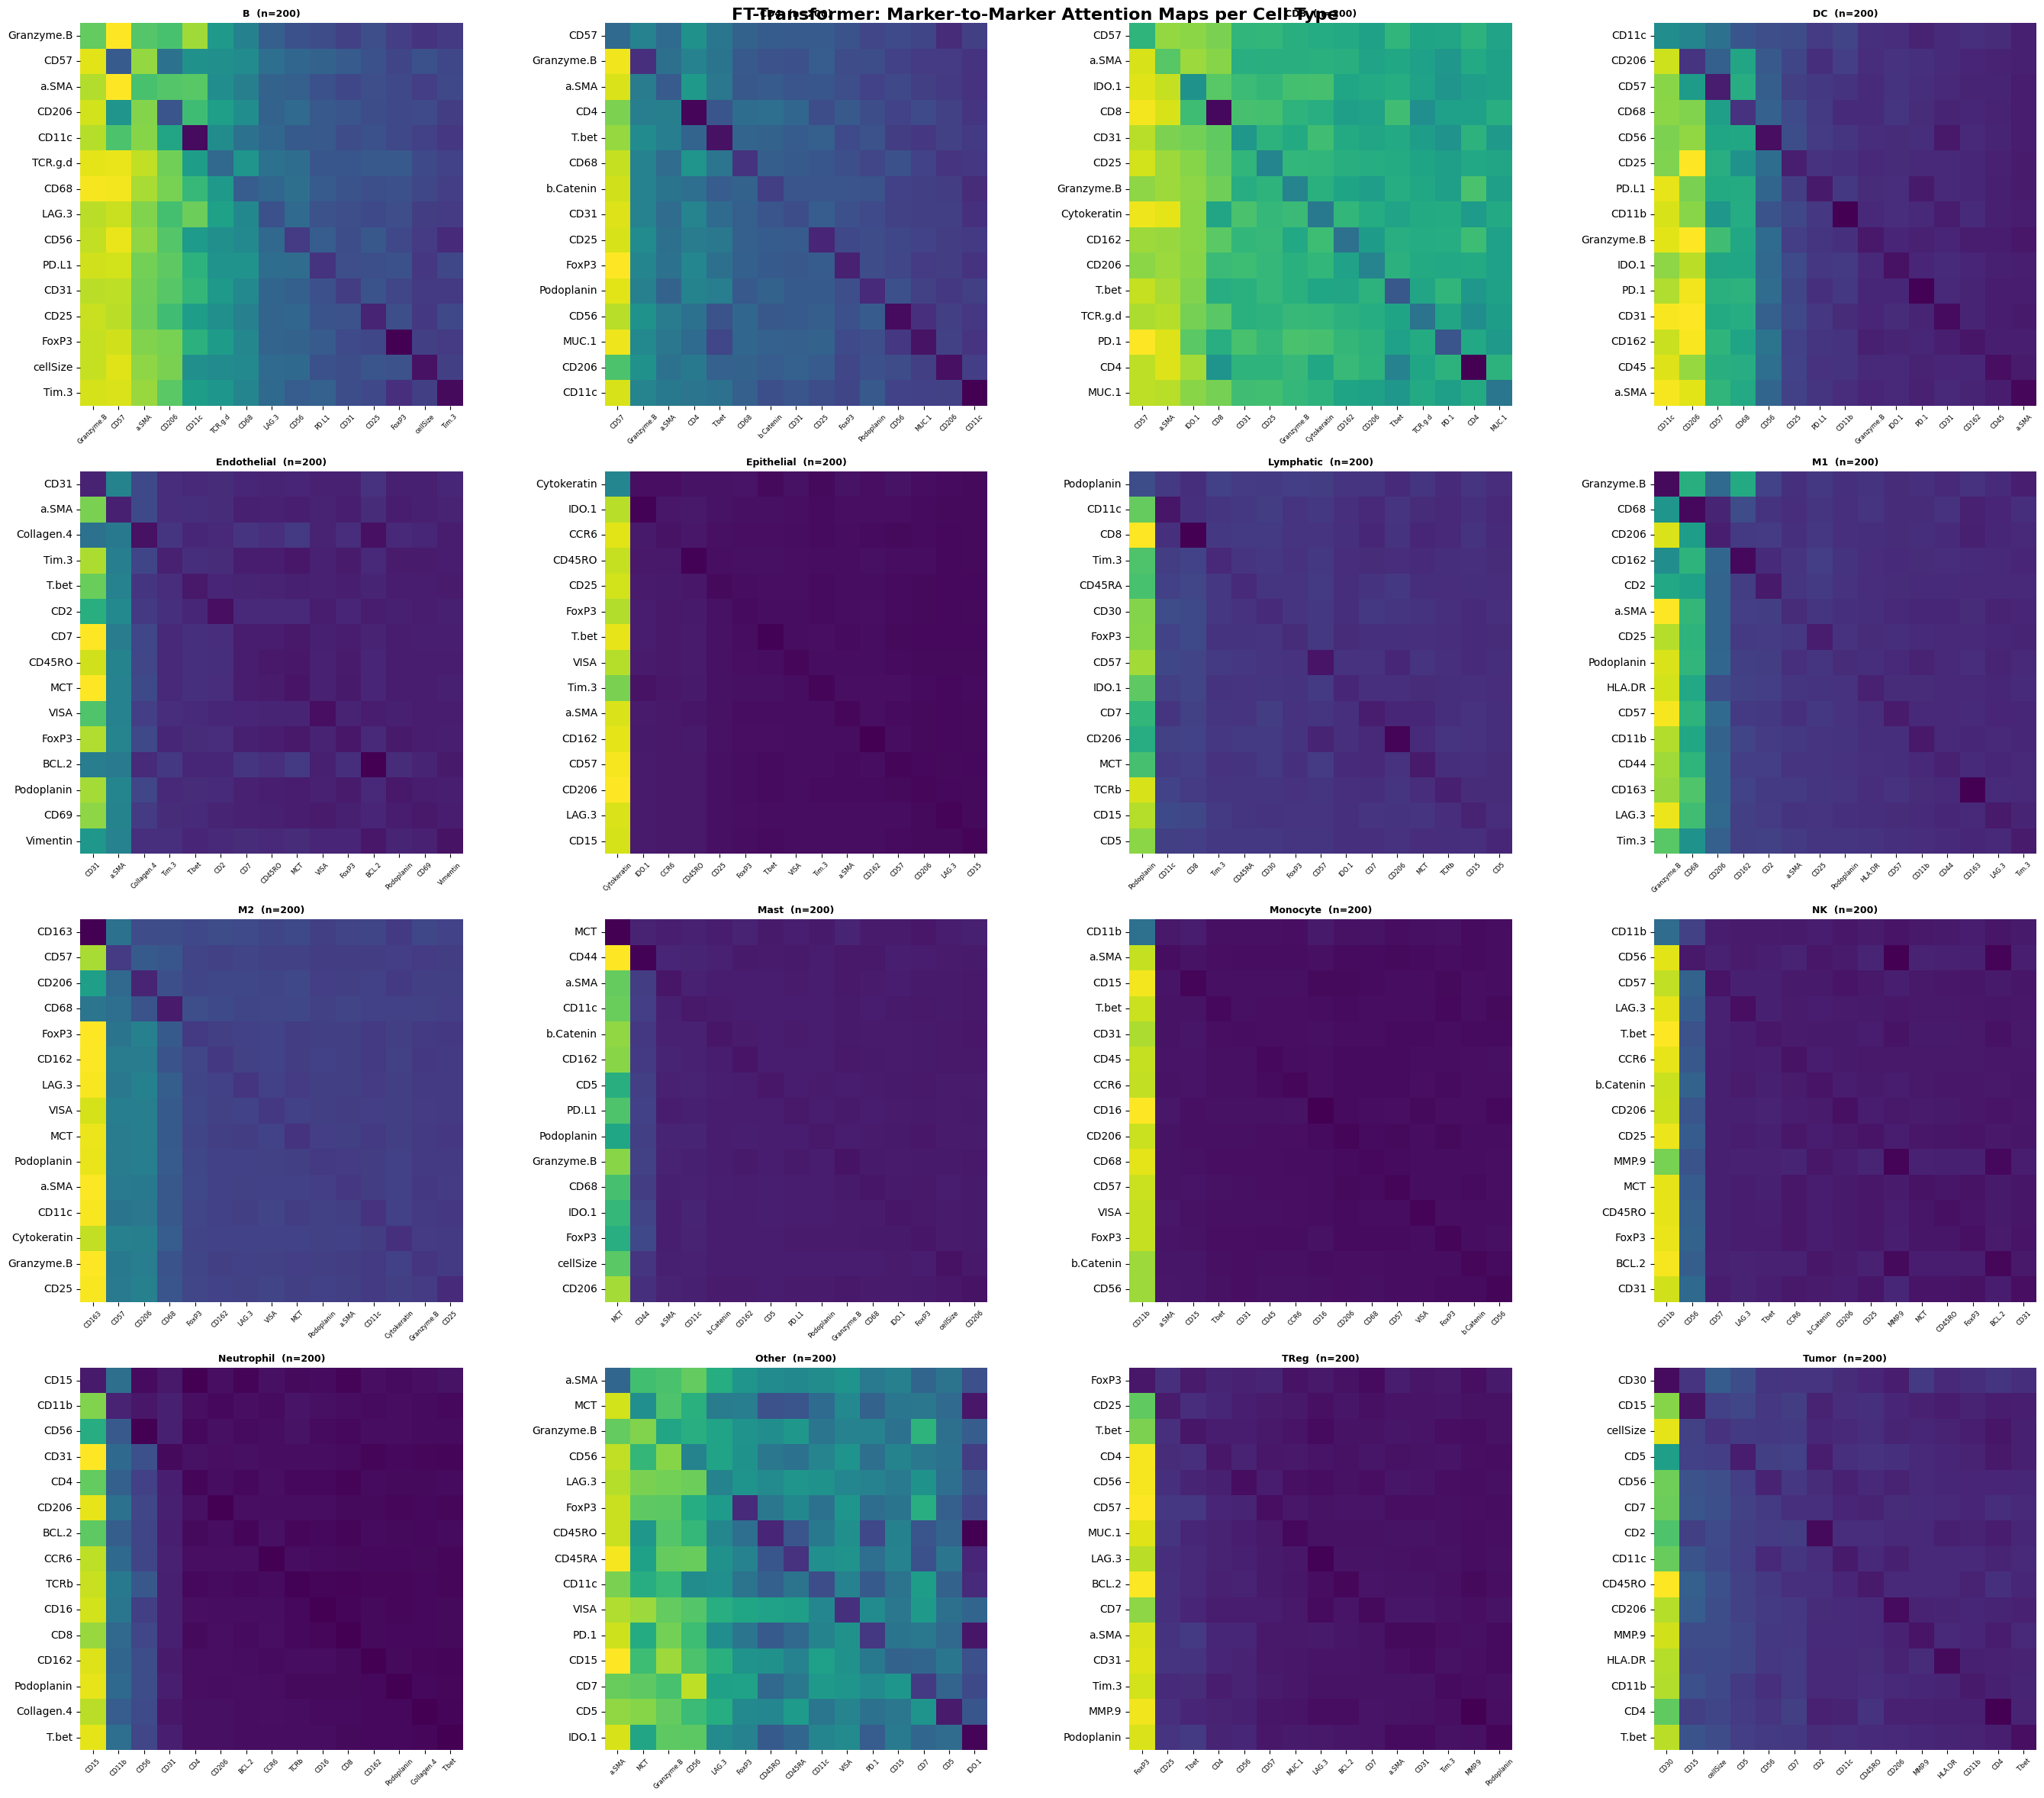

In [9]:
# Extract attention maps for a subset of cells
sample_indices = []
for c in range(NUM_CLASSES):
    idx = np.where(y_valid == c)[0]
    sample_indices.extend(idx[:200].tolist())
sample_indices = np.array(sample_indices)

X_sample = torch.tensor(X_valid_sc[sample_indices], dtype=torch.float32)
y_sample = y_valid[sample_indices]

ft_model.eval()
attn_all = []
bs = 128
for start in range(0, len(X_sample), bs):
    batch = X_sample[start:start+bs].to(DEVICE)
    maps = ft_model.get_attention_maps(batch)
    last_layer = maps[-1]  # (B, n_heads, F+1, F+1)
    avg_heads = last_layer.mean(dim=1)
    marker_attn = avg_heads[:, 1:, 1:]  # (B, F, F)
    attn_all.append(marker_attn.numpy())

attn_all = np.concatenate(attn_all, axis=0)  # (N_sample, 50, 50)

fig, axes = plt.subplots(4, 4, figsize=(28, 24))
axes = axes.flatten()

for c in range(NUM_CLASSES):
    mask = (y_sample == c)
    if mask.sum() == 0:
        axes[c].set_visible(False)
        continue
    avg_attn = attn_all[mask].mean(axis=0)
    top_idx = avg_attn.sum(axis=0).argsort()[-15:][::-1]
    sub = avg_attn[np.ix_(top_idx, top_idx)]
    labels = [FEATURE_COLS[i] for i in top_idx]

    sns.heatmap(sub, ax=axes[c], xticklabels=labels, yticklabels=labels, cmap='viridis', cbar=False, square=True)
    axes[c].set_title(f'{CLASS_NAMES[c]}  (n={mask.sum()})', fontsize=9, fontweight='bold')
    axes[c].tick_params(axis='x', rotation=45, labelsize=6)

plt.suptitle('FT-Transformer: Marker-to-Marker Attention Maps per Cell Type', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('ft_transformer_attention_heatmaps.png', dpi=150)
plt.show()


---
# PART III: Biological Validation (Attention vs Trees)
Are our neural networks and our decision trees learning the same underlying biology to make their annotations? 
We compare the global Attention Importance from the Transformer against the Feature Gain Importance from LightGBM using a Spearman rank correlation.


Spearman rank correlation (LGB vs Attention): r=0.341, p=0.0154


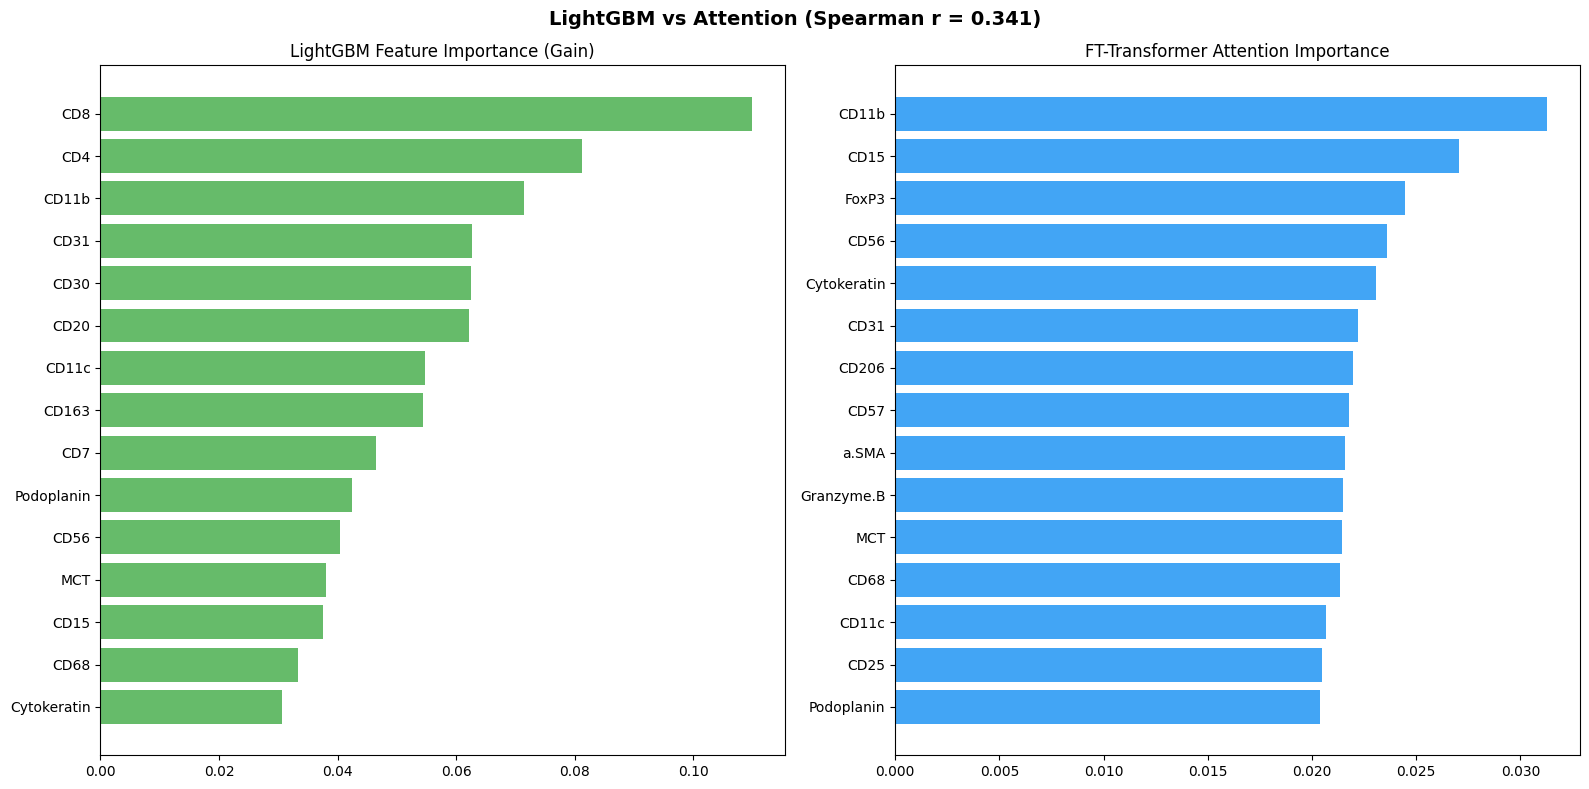

In [10]:
# Train LightGBM to get feature importance
lgb_train_ds = lgb.Dataset(X_train_sc, label=y_train, feature_name=FEATURE_COLS)
lgb_params = {'objective': 'multiclass', 'num_class': 16, 'verbose': -1, 'seed': 7325111, 'learning_rate': 0.05}
lgb_model = lgb.train(lgb_params, lgb_train_ds, num_boost_round=500)

lgb_imp = lgb_model.feature_importance(importance_type='gain')
lgb_imp_norm = lgb_imp / lgb_imp.sum()
lgb_rank = lgb_imp_norm.argsort()[::-1]

attn_global = attn_all.mean(axis=0)
attn_importance = attn_global.sum(axis=0)
attn_imp_norm = attn_importance / attn_importance.sum()
attn_rank = attn_imp_norm.argsort()[::-1]

corr, pval = spearmanr(lgb_imp_norm, attn_imp_norm)
print(f"Spearman rank correlation (LGB vs Attention): r={corr:.3f}, p={pval:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
top_n = 15
ax1.barh(range(top_n), lgb_imp_norm[lgb_rank[:top_n]][::-1], color='#66BB6A')
ax1.set_yticks(range(top_n))
ax1.set_yticklabels([FEATURE_COLS[i] for i in lgb_rank[:top_n]][::-1])
ax1.set_title('LightGBM Feature Importance (Gain)')

ax2.barh(range(top_n), attn_imp_norm[attn_rank[:top_n]][::-1], color='#42A5F5')
ax2.set_yticks(range(top_n))
ax2.set_yticklabels([FEATURE_COLS[i] for i in attn_rank[:top_n]][::-1])
ax2.set_title('FT-Transformer Attention Importance')

plt.suptitle(f'LightGBM vs Attention (Spearman r = {corr:.3f})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tree_vs_attention_importance.png')
plt.show()


---
# PART IV: Clinical Cost Reduction (Minimal Annotation Panel)
Finally, we apply our findings to a practical clinical problem. Using the feature importance rankings, we determine the absolute minimum number of protein markers needed to maintain a 90% F1 annotation score, effectively reducing the cost of the spatial proteomics panel.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Top  5 markers: F1 = 0.5275


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Top  8 markers: F1 = 0.6701


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

Top 30 markers: F1 = 0.8951


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Top 40 markers: F1 = 0.8962


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Top 50 markers: F1 = 0.8957


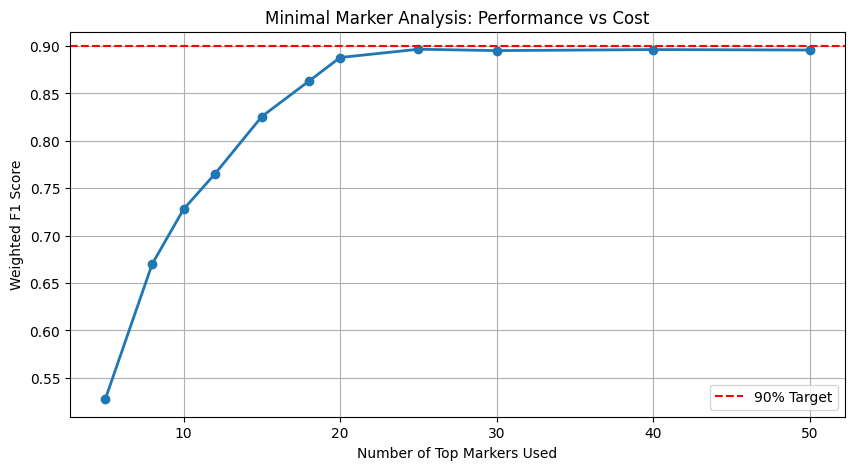

In [11]:
results = {}
for k in [5, 8, 10, 12, 15, 18, 20, 25, 30, 40, 50]:
    top_k_idx = lgb_rank[:k]
    clf = lgb.LGBMClassifier(objective='multiclass', num_class=16, verbose=-1, random_state=7325111)
    clf.fit(X_train_sc[:, top_k_idx], y_train)
    score = f1_score(y_valid, clf.predict(X_valid_sc[:, top_k_idx]), average='weighted')
    results[k] = score
    print(f"Top {k:2d} markers: F1 = {score:.4f}")

min_90 = next((k for k, v in results.items() if v >= 0.90), None)
if min_90:
    print(f"\nSUCCESS: Reached 90% F1 using only {min_90} markers!")
    print(f"Cost Reduction: {round((1 - min_90/50)*100)}%")

fig, ax = plt.subplots(figsize=(10, 5))
ks = list(results.keys()); f1s = list(results.values())
ax.plot(ks, f1s, marker='o', linewidth=2)
ax.axhline(0.90, color='red', linestyle='--', label='90% Target')
if min_90:
    ax.axvline(min_90, color='green', linestyle=':', label=f'Minimum: {min_90}')
ax.set_title("Minimal Marker Analysis: Performance vs Cost")
ax.set_xlabel("Number of Top Markers Used"); ax.set_ylabel("Weighted F1 Score")
ax.legend(); ax.grid(True)
plt.show()
